# 01 — Exploration et Analyse des Données (EDA)

**Objectifs de ce notebook :**
- Compter et visualiser la distribution des classes
- Afficher des exemples d'images (NORMAL vs PNEUMONIA)
- Analyser les dimensions et les statistiques des images
- Détecter les images corrompues

> **Jour J2 du plan de 10 jours**

In [1]:
import os
import sys
from pathlib import Path

# Ajouter src/ au path pour importer nos modules
sys.path.insert(0, str(Path('..') / 'src'))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image
import pandas as pd

from utils import set_seed, count_classes

# Reproductibilité
set_seed(42)

# Chemin vers le dataset
DATA_DIR = Path('..') / 'data' / 'chest_xray'
print(f'Dataset path : {DATA_DIR.resolve()}')

  Seed fixée à 42 ✓
Dataset path : C:\PROJET FINAL DL\medical-cnn-project\data\chest_xray


## 1. Distribution des classes

In [2]:
# Comptage par split et par classe
distribution = count_classes(str(DATA_DIR))

# Tableau récapitulatif
rows = []
for split, counts in distribution.items():
    for cls, n in counts.items():
        rows.append({'Split': split, 'Classe': cls, 'Nombre': n})
df = pd.DataFrame(rows)
pivot = df.pivot(index='Classe', columns='Split', values='Nombre')
pivot['Total'] = pivot.sum(axis=1)
print(pivot)

# Ratio déséquilibre dans train
train_normal    = distribution['train']['NORMAL']
train_pneumonia = distribution['train']['PNEUMONIA']
ratio = train_pneumonia / train_normal
print(f'\nRatio PNEUMONIA/NORMAL (train) : {ratio:.2f}x')
print('→ Déséquilibre à compenser avec pos_weight dans la loss.')


  Distribution des classes :
  [train] NORMAL: 1341, PNEUMONIA: 3875  |  Total: 5216
  [val  ] NORMAL: 8, PNEUMONIA: 8  |  Total: 16
  [test ] NORMAL: 234, PNEUMONIA: 390  |  Total: 624
Split      test  train  val  Total
Classe                            
NORMAL      234   1341    8   1583
PNEUMONIA   390   3875    8   4273

Ratio PNEUMONIA/NORMAL (train) : 2.89x
→ Déséquilibre à compenser avec pos_weight dans la loss.


C:\Users\bongu\AppData\Local\Temp\ipykernel_37128\473420519.py:18: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


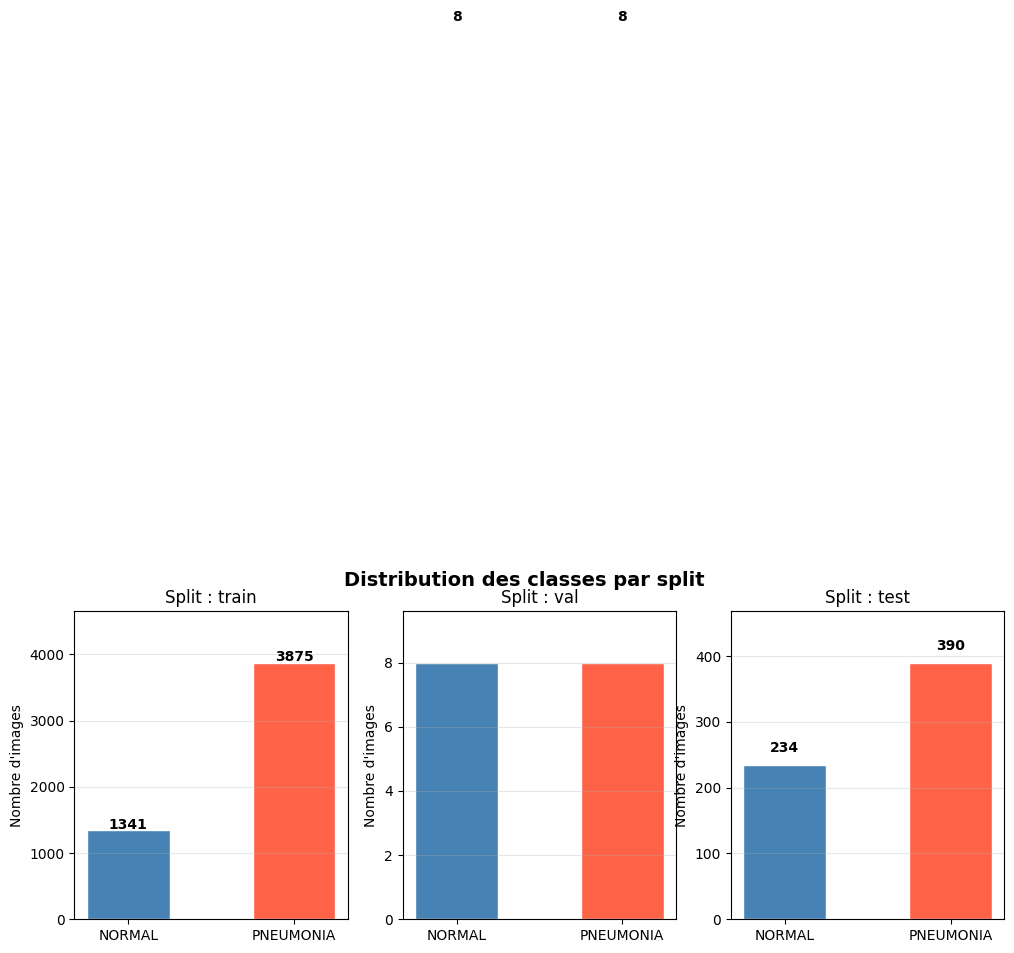

Saved → outputs/figures/class_distribution.png


In [3]:
# Visualisation en barres groupées
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
colors = {'NORMAL': 'steelblue', 'PNEUMONIA': 'tomato'}

for ax, split in zip(axes, ['train', 'val', 'test']):
    counts = distribution[split]
    ax.bar(counts.keys(), counts.values(),
           color=[colors[k] for k in counts.keys()], edgecolor='white', width=0.5)
    for cls, n in counts.items():
        ax.text(list(counts.keys()).index(cls), n + 20, str(n),
                ha='center', fontweight='bold')
    ax.set_title(f'Split : {split}', fontsize=12)
    ax.set_ylabel('Nombre d\'images')
    ax.set_ylim(0, max(counts.values()) * 1.2)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Distribution des classes par split', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/class_distribution.png', dpi=150)
plt.show()
print('Saved → outputs/figures/class_distribution.png')

## 2. Exemples d'images

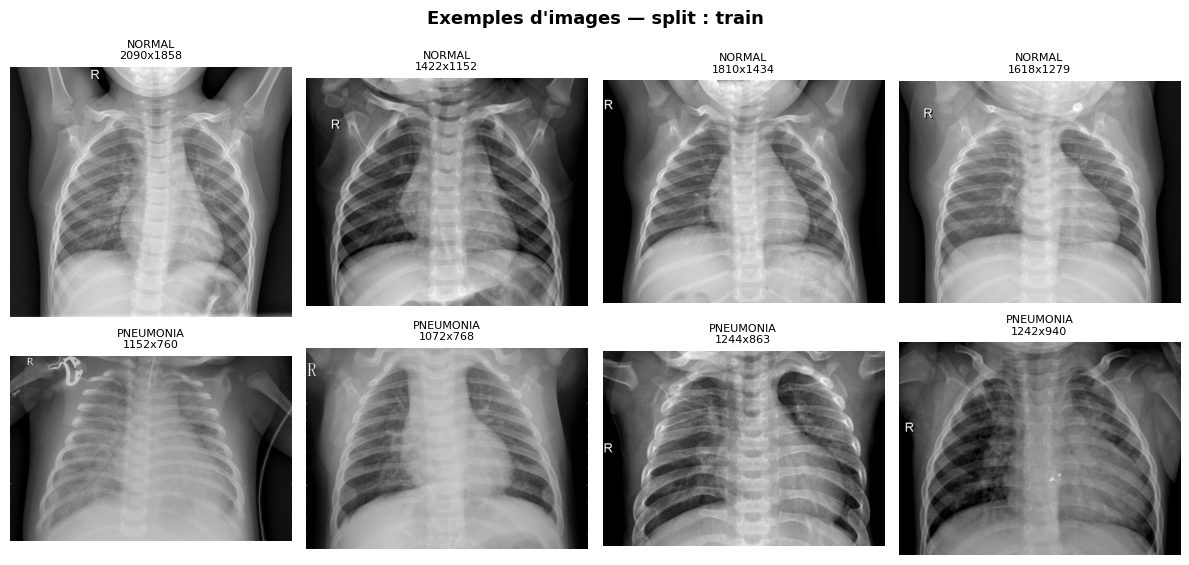

In [4]:
def show_samples(data_dir: Path, split: str = 'train', n_per_class: int = 4):
    """Affiche n_per_class exemples par classe."""
    fig, axes = plt.subplots(2, n_per_class, figsize=(3 * n_per_class, 6))
    
    for row, cls in enumerate(['NORMAL', 'PNEUMONIA']):
        cls_dir = data_dir / split / cls
        files = sorted(cls_dir.glob('*.jpeg'))[:n_per_class]
        for col, f in enumerate(files):
            img = Image.open(f).convert('RGB')
            axes[row, col].imshow(img, cmap='gray')
            axes[row, col].set_title(f'{cls}\n{img.size[0]}x{img.size[1]}', fontsize=8)
            axes[row, col].axis('off')
    
    plt.suptitle(f'Exemples d\'images — split : {split}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'../outputs/figures/samples_{split}.png', dpi=150)
    plt.show()

show_samples(DATA_DIR, split='train', n_per_class=4)

## 3. Analyse des dimensions d'images

=== Statistiques des dimensions (px) ===
        width  height
count   200.0   200.0
mean   1418.0  1083.6
std     349.2   377.8
min     457.0   295.0
25%    1162.0   790.0
50%    1408.0  1067.5
75%    1645.0  1323.0
max    2450.0  2325.0


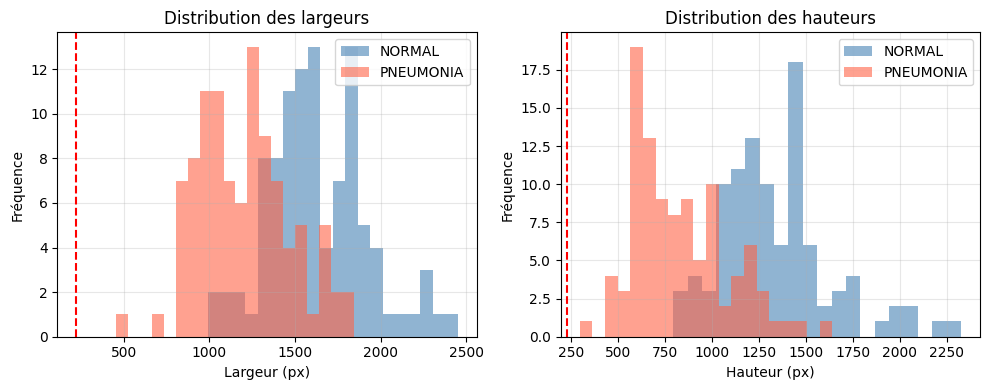

In [5]:
# Échantillonnage de 200 images train pour analyser les tailles
import random
random.seed(42)

sizes = []
for cls in ['NORMAL', 'PNEUMONIA']:
    files = list((DATA_DIR / 'train' / cls).glob('*.jpeg'))
    sample = random.sample(files, min(100, len(files)))
    for f in sample:
        with Image.open(f) as img:
            sizes.append({'classe': cls, 'width': img.size[0], 'height': img.size[1]})

df_sizes = pd.DataFrame(sizes)
print('=== Statistiques des dimensions (px) ===')
print(df_sizes[['width', 'height']].describe().round(1))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, col, label in zip(axes, ['width', 'height'], ['Largeur', 'Hauteur']):
    for cls, color in zip(['NORMAL', 'PNEUMONIA'], ['steelblue', 'tomato']):
        data = df_sizes[df_sizes['classe'] == cls][col]
        ax.hist(data, bins=20, alpha=0.6, color=color, label=cls)
    ax.set_xlabel(f'{label} (px)')
    ax.set_ylabel('Fréquence')
    ax.set_title(f'Distribution des {label.lower()}s')
    ax.legend()
    ax.axvline(224, color='red', linestyle='--', label='Cible 224px')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/figures/image_dimensions.png', dpi=150)
plt.show()

## 4. Détection d'images corrompues

In [6]:
corrupted = []
total_checked = 0

for split in ['train', 'val', 'test']:
    for cls in ['NORMAL', 'PNEUMONIA']:
        folder = DATA_DIR / split / cls
        for f in folder.glob('*.jpeg'):
            total_checked += 1
            try:
                with Image.open(f) as img:
                    img.verify()  # vérifie l'intégrité sans charger les pixels
            except Exception as e:
                corrupted.append({'file': str(f), 'error': str(e)})

print(f'Images vérifiées : {total_checked}')
print(f'Images corrompues : {len(corrupted)}')

if corrupted:
    df_corrupted = pd.DataFrame(corrupted)
    print('\nFichiers corrompus :')
    print(df_corrupted)
else:
    print('Aucune image corrompue detectee - OK')

Images vérifiées : 5856
Images corrompues : 0
Aucune image corrompue detectee - OK


## 5. Résumé EDA

In [7]:
print('=== RÉSUMÉ EDA ===')
print(f'Total images      : {sum(sum(c.values()) for c in distribution.values())}')
print(f'Classes           : NORMAL (0) vs PNEUMONIA (1)')
print(f'Déséquilibre train: {ratio:.2f}x en faveur de PNEUMONIA')
print(f'Taille cible      : 224x224 px (resize appliqué par dataset.py)')
print(f'Images corrompues : {len(corrupted)}')
print()
print('Actions recommandées :')
print('  - Utiliser pos_weight=0.33 dans BCEWithLogitsLoss')
print('  - Appliquer RandomHorizontalFlip et légère rotation en augmentation')
print('  - Surveiller prioritairement le Recall (FN = pneumonie non détectée)')

=== RÉSUMÉ EDA ===
Total images      : 5856
Classes           : NORMAL (0) vs PNEUMONIA (1)
Déséquilibre train: 2.89x en faveur de PNEUMONIA
Taille cible      : 224x224 px (resize appliqué par dataset.py)
Images corrompues : 0

Actions recommandées :
  - Utiliser pos_weight=0.33 dans BCEWithLogitsLoss
  - Appliquer RandomHorizontalFlip et légère rotation en augmentation
  - Surveiller prioritairement le Recall (FN = pneumonie non détectée)
